In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil
import scipy.optimize

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from analysis_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
solo_results = pd.read_excel("/home/sak0914/who-analysis/results/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

# CRyPTIC Essential Agreements (for comparing to Lachapelle et al., 2021)

In [2]:
def compute_cryptic_EA(drug, path, thresh):

    test_pred = pd.read_csv(os.path.join(results_path, path, "test_predictions.csv"))
    df_phenos = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    
    test_pred_cryptic = test_pred.loc[test_pred["Isolate"].isin(df_phenos.query("DB_OF_ORIGIN=='CRyPTIC'").ROLLINGDB_ID.values)]

    # y_test column is log2-transformed
    test_pred_cryptic_R = test_pred_cryptic.query("y_test > @thresh")
    test_pred_cryptic_S = test_pred_cryptic.query("y_test <= @thresh")
    print(len(test_pred), len(test_pred_cryptic), len(test_pred_cryptic_R), len(test_pred_cryptic_S))
    
    print(f"\nFull: {np.round(test_pred.within_doubling.mean(), 3)}")
    print(f"CRyPTIC: {np.round(test_pred_cryptic.within_doubling.mean(), 3)}")
    print(f"CRyPTIC-R: {np.round(test_pred_cryptic_R.within_doubling.mean(), 3)}")
    print(f"CRyPTIC-S: {np.round(test_pred_cryptic_S.within_doubling.mean(), 3)}")

In [ ]:
# drug = "RIF"
# path = "RIF_rpoBC"
# compute_cryptic_EA(drug, path, np.log2(0.5))

In [ ]:
drug = "INH"
path = "INH_4Loci"
compute_cryptic_EA(drug, path, np.log2(0.2))

In [ ]:
drug = "EMB"
path = "EMB_2Loci"
compute_cryptic_EA(drug, path, np.log2(5))

In [49]:
drug = "MXF"
path = "MXF_gyrBA_lineage"
compute_cryptic_EA(drug, path, np.log2(0.5))

1454 1216 186 1030

Full: 0.9
CRyPTIC: 0.921
CRyPTIC-R: 0.876
CRyPTIC-S: 0.929


# Replicates Evaluation

Plot validation loss for the 10 replicates and the actual model on top. 

In [3]:
# plot_histories(os.path.join(results_path, "RIF_rpoABC"), binary=False, patience_epochs=100, replicates=True)

Trained replicate rep_0 for 407 epochs (excluding patience period)
Trained replicate rep_1 for 349 epochs (excluding patience period)
Trained replicate rep_2 for 277 epochs (excluding patience period)
Trained replicate rep_3 for 309 epochs (excluding patience period)
Trained replicate rep_4 for 272 epochs (excluding patience period)
Trained replicate rep_5 for 230 epochs (excluding patience period)
Trained replicate rep_6 for 397 epochs (excluding patience period)
Trained replicate rep_7 for 337 epochs (excluding patience period)
Trained replicate rep_8 for 390 epochs (excluding patience period)
Trained replicate rep_9 for 417 epochs (excluding patience period)


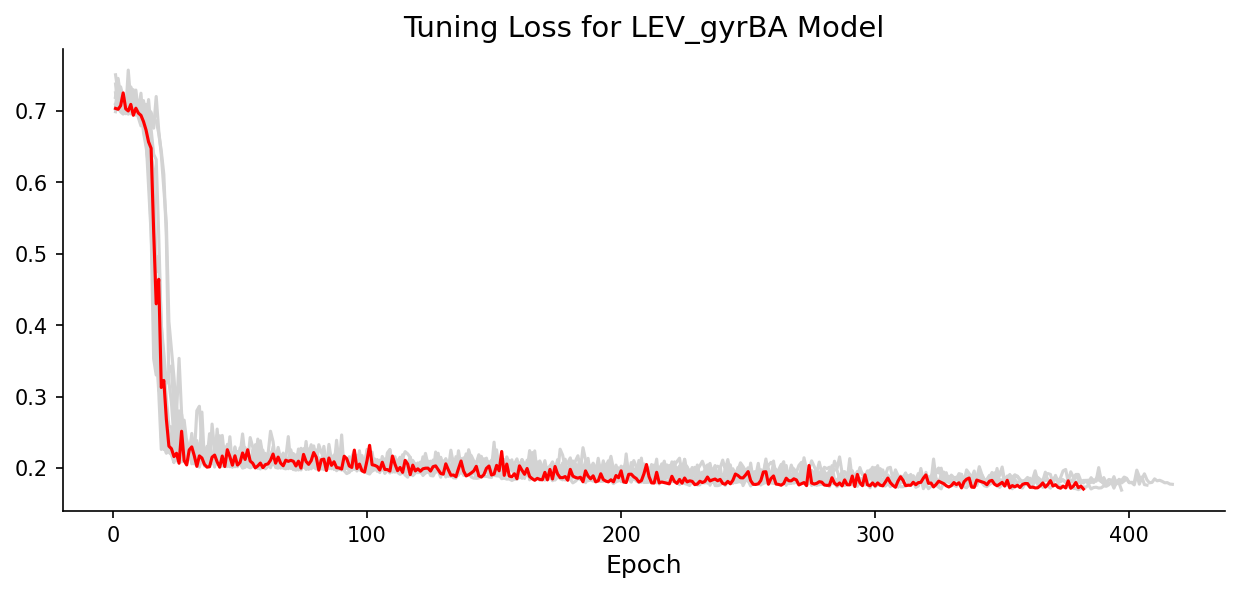

In [4]:
plot_histories(os.path.join(results_path, "LEV_gyrBA"), binary=False, patience_epochs=100, replicates=True)

Trained replicate rep_0 for 199 epochs (excluding patience period)
Trained replicate rep_1 for 133 epochs (excluding patience period)
Trained replicate rep_2 for 101 epochs (excluding patience period)
Trained replicate rep_3 for 132 epochs (excluding patience period)
Trained replicate rep_4 for 85 epochs (excluding patience period)
Trained replicate rep_5 for 145 epochs (excluding patience period)
Trained replicate rep_6 for 219 epochs (excluding patience period)
Trained replicate rep_7 for 74 epochs (excluding patience period)
Trained replicate rep_8 for 189 epochs (excluding patience period)
Trained replicate rep_9 for 129 epochs (excluding patience period)


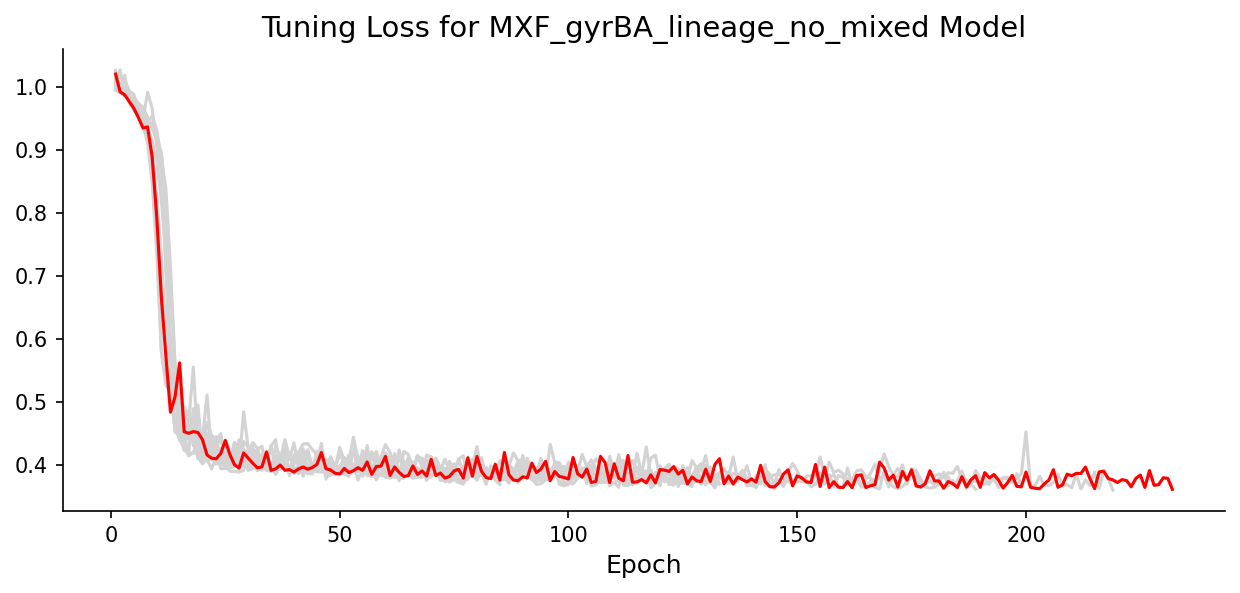

In [3]:
plot_histories(os.path.join(results_path, "MXF_gyrBA_lineage_no_mixed"), binary=False, patience_epochs=100, replicates=True)

Trained replicate rep_0 for 1136 epochs (excluding patience period)
Trained replicate rep_1 for 1861 epochs (excluding patience period)
Trained replicate rep_2 for 919 epochs (excluding patience period)
Trained replicate rep_3 for 1600 epochs (excluding patience period)
Trained replicate rep_4 for 815 epochs (excluding patience period)
Trained replicate rep_5 for 723 epochs (excluding patience period)
Trained replicate rep_6 for 983 epochs (excluding patience period)
Trained replicate rep_7 for 736 epochs (excluding patience period)
Trained replicate rep_8 for 812 epochs (excluding patience period)
Trained replicate rep_9 for 1717 epochs (excluding patience period)


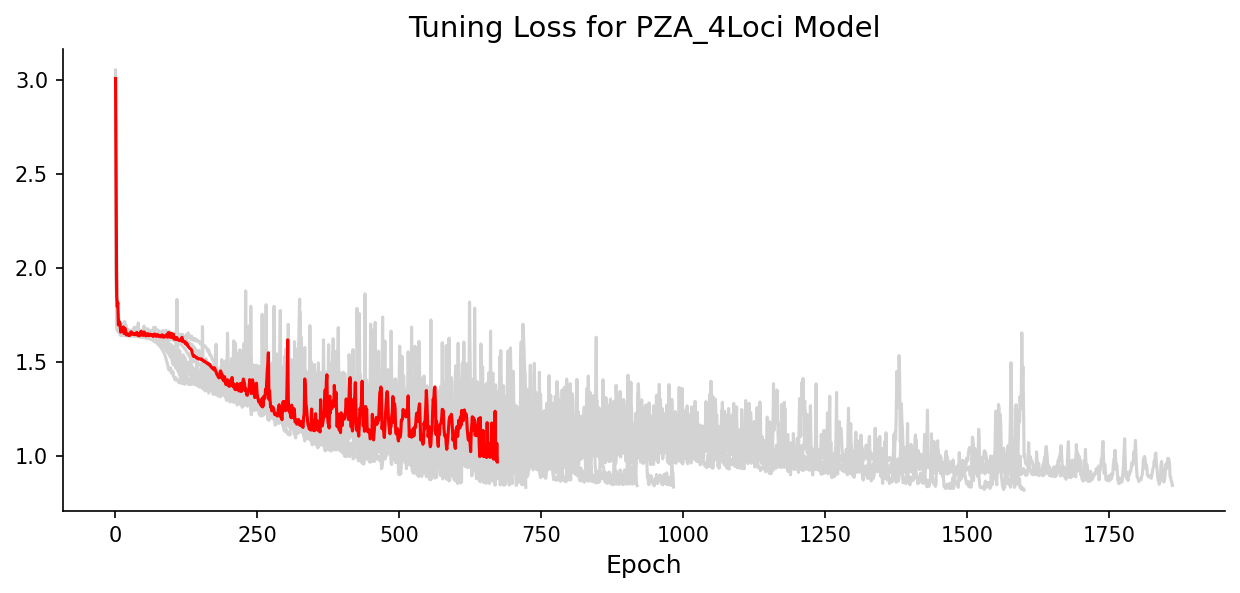

In [2]:
plot_histories(os.path.join(results_path, "PZA_4Loci"), binary=False, patience_epochs=150, replicates=True)

Trained replicate rep_0 for 740 epochs (excluding patience period)
Trained replicate rep_1 for 1000 epochs (excluding patience period)
Trained replicate rep_2 for 983 epochs (excluding patience period)
Trained replicate rep_3 for 538 epochs (excluding patience period)
Trained replicate rep_4 for 1067 epochs (excluding patience period)
Trained replicate rep_5 for 664 epochs (excluding patience period)
Trained replicate rep_6 for 751 epochs (excluding patience period)
Trained replicate rep_7 for 842 epochs (excluding patience period)
Trained replicate rep_8 for 883 epochs (excluding patience period)
Trained replicate rep_9 for 1202 epochs (excluding patience period)


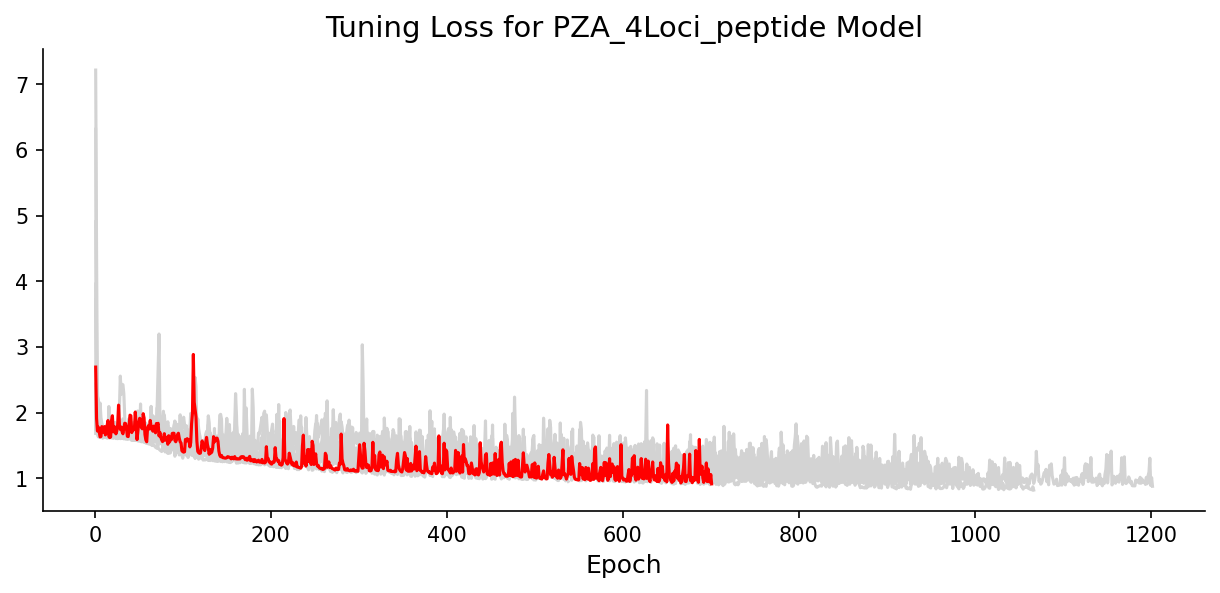

In [3]:
plot_histories(os.path.join(results_path, "PZA_4Loci_peptide"), binary=False, patience_epochs=150, replicates=True)

# Analyze quantitative CNN

In [4]:
def plot_model_results(df, variable_lst, tick_labels, sharey, meanLine_width=0.3, lower_bounds=None, upper_bounds=None, savefName=None):
    
    if len(variable_lst) <= 3:
        col_wrap = None
    else:
        col_wrap =2
    
    plot_df = df.query("CV > 0").melt(id_vars=["Model", "Lineage"], value_vars=variable_lst)
    plot_df["Model"] = plot_df["Model"].replace("LinReg", "Regression")
    plot_df["Model"] = plot_df["Model"].replace("LogReg", "Regression")
    
    palette = sns.color_palette("Set2").as_hex()
    color_dict = dict(zip(plot_df.Model.unique(), palette[:len(plot_df.Model.unique())]))
        
    g = sns.catplot(data=plot_df, 
                    x="Lineage", 
                    y="value", 
                    hue="Model", 
                    col="variable", 
                    col_order=variable_lst,
                    col_wrap=col_wrap,
                    hue_order=["Regression", "CNN"], 
                    kind="strip", 
                    dodge=True,
                    aspect=0.9, 
                    height=4, 
                    linewidth=0.5,
                    palette=color_dict,
                    sharex=False,
                    sharey=sharey,
                    legend_out=True
                   )

    for i, (col_name, ax) in enumerate(g.axes_dict.items()):

        sns.pointplot(data=plot_df.query("variable == @col_name"),
                      x="Lineage", 
                      y="value", 
                      hue="Model", 
                      hue_order=["Regression", "CNN"], 
                      palette=color_dict, 
                      dodge=0.4, 
                      join=False, 
                      ci=0, 
                      errwidth=2, # thickness
                      capsize=meanLine_width,  # height
                      scale=0, 
                      ax=ax
                     )

        if not sharey:
            if type(lower_bounds) == np.ndarray or type(lower_bounds) == list:
                ax.set_ylim(lower_bounds[i], upper_bounds[i])

        # don't add another legend from the pointplot function
        ax.get_legend().remove()


    # put a box around the legend
    sns.move_legend(g, title="", loc="center right", frameon=True, fontsize="small")

    g.set(xlabel=None, ylabel=None)
    g.set_titles(template='{col_name}\n')
    g.set_xticklabels(tick_labels)

    if sharey:
        if lower_bound is not None and upper_bound is not None:
            g.set(ylim=(lower_bound, upper_bound))
    
    sns.despine()
    # plt.tight_layout()
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)

In [5]:
def plot_ridge_results(path, saveName=None):
    
    pred_df = pd.read_csv(os.path.join(path, "ridge/test_predictions.csv"))
                          
    fig, ax = plt.subplots(figsize=(5, 4))
    
    values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
    kernel = st.gaussian_kde(values)(values)

    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="y_test",
        c=kernel,
        cmap="Blues",
        linewidth=0.25,
        edgecolor="lightgray",
        ax=ax
    )
    
    max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
    min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

    ax.set_xlabel("\nPredicted MIC (µg/mL)", fontsize=9)
    ax.set_ylabel("Actual MIC (µg/mL)", fontsize=9)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    # ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
#     max_log2 = 10
#     ax.set_xticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
#     ax.set_yticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
    
    # smallest_power = -6
    # largest_power = 3
    smallest_power = np.floor(np.min([pred_df.y_pred, pred_df.y_test]))
    largest_power = np.ceil(np.max([pred_df.y_pred, pred_df.y_test]))
    smallest_power = -8
    
    tick_labels = []

    for num in np.exp2(np.linspace(smallest_power, largest_power, 11)):
        if num < 1:
            tick_labels.append(str(np.round(num, 2)))
        else:
            tick_labels.append(str(int(num)))
        
    ax.set_xticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    ax.set_yticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)
        
        
        
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    assert sum(~pd.isnull(x1.query("CV>0")[var].values)) == sum(~pd.isnull(x2.query("CV>0")[var].values))
    return st.mannwhitneyu(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        
        
def compare_two_models(model_1, model_2, test_variables=["Binned_MAE", "Binned_MSE", "Spearman", "Within_1Bin", "Within_doubling", "Sensitivity", "Specificity", "Balanced_Acc"]):
    '''
    Directionality is important. Put the one hypothesized to be better FIRST
    '''
    # lineage does not significantly improve RIF prediction
    for var in test_variables:

        pval = test_for_significance(model_1, model_2, var, alt="two-sided")

        # if the two-sided test is significant, then try one-sided, based on the variable
        if pval < 0.05:

            if "MAE" in var or "MSE" in var or "Without" in var:
                alt = "less"
            else:
                alt = "greater"
        
            pval = test_for_significance(model_1, model_2, var, alt=alt)
            
            if pval < 0.05:
                print(f"{var} better, pval = {pval}")
            else:
                print(f"{var} worse, pval = {1-pval}")
        else:
            print(f"{var}, ns = {pval}")

In [7]:
def get_single_model_results(drug, path, include_lineage=False, include_peptide_length=False, patience=100, bs=True, plot=True):
    '''
    Gets results for lineage and regression, using kwargs
    '''

    if include_lineage and include_peptide_length:
        raise ValueError("Both cannot be the true")
    
    drug_abbr = drug_abbr_dict[drug]
    model_results_lst = []
    
    df_CNN = quant_model_analysis(os.path.join(results_path, path), drug_abbr, lineage=0, patience=patience, bs=bs, plot=plot, saveName=f"{drug}/CNN_predictions.png")
    df_CNN["Lineage"] = 0
    
    df_Reg = pd.read_csv(os.path.join(results_path, path, "ridge/results.csv"))
    df_Reg["Lineage"] = 0
    
    model_results_lst.append(df_CNN)
    model_results_lst.append(df_Reg)
    
    if include_lineage:
        df_CNN_lineage = quant_model_analysis(os.path.join(results_path, f"{path}_lineage"), drug_abbr, lineage=1, patience=patience, bs=bs, plot=plot)
        df_Reg_lineage = pd.read_csv(os.path.join(results_path, f"{path}_lineage/ridge/results.csv"))

    elif include_peptide_length:
        df_CNN_lineage = quant_model_analysis(os.path.join(results_path, f"{path}_peptide"), drug_abbr, lineage=1, patience=patience, bs=bs, plot=plot)
        df_Reg_lineage = pd.read_csv(os.path.join(results_path, f"{path}_peptide/ridge/results.csv"))
        
    df_CNN_lineage["Lineage"] = 1     
    df_Reg_lineage["Lineage"] = 1
    model_results_lst.append(df_CNN_lineage)
    model_results_lst.append(df_Reg_lineage)

    if bs:
        df_bs_Reg = pd.read_csv(os.path.join(results_path, path, "ridge/bootstrapping/results.csv"))
        df_bs_Reg["Lineage"] = 0
        model_results_lst.append(df_bs_Reg)
        
        if include_lineage:
            df_bs_Reg_lineage = pd.read_csv(os.path.join(results_path, f"{path}_lineage/ridge/bootstrapping/results.csv"))

        elif include_peptide_length:
            df_bs_Reg_lineage = pd.read_csv(os.path.join(results_path, f"{path}_peptide/ridge/bootstrapping/results.csv"))
            
        df_bs_Reg_lineage["Lineage"] = 1
        model_results_lst.append(df_bs_Reg_lineage)

    df_combined = pd.concat(model_results_lst, axis=0)
    # df_combined["Without_1Bin"] = 1 - df_combined["Within_1Bin"]
    df_combined["Without_doubling"] = 1 - df_combined["Within_doubling"]
    return df_combined.reset_index(drop=True)

# All Drugs

In [21]:
all_drugs_results = []
all_drugs_catalog_results = []

# for drug, model_path in list(zip(["Rifampicin", "Moxifloxacin", "Isoniazid", "Ethambutol"],
#                                  ["RIF_rpoABC", "MXF_gyrBA_old", "INH_4Loci", "EMB_2Loci"]
#                                 )):

for drug, model_path in list(zip(["Rifampicin", "Moxifloxacin", "Levofloxacin", "Pyrazinamide"],
                                 ["RIF_rpoABC", "MXF_gyrBA", "LEV_gyrBA", "PZA_4Loci"]
                                )):
    if drug == "Pyrazinamide":
        patience_epochs = 150
        include_lineage = False
        include_peptide_length = True
    else:
        patience_epochs = 100
        include_lineage = True
        include_peptide_length = False

    # include_lineage = True
    # include_peptide_length = False
    
    df = get_single_model_results(drug, model_path, include_lineage=include_lineage, include_peptide_length=include_peptide_length, patience=patience_epochs, bs=True, plot=False)
    all_drugs_results.append(df)

    if "lineage" not in model_path:
        df_binary = pd.read_csv(os.path.join(results_path, model_path.replace("_peptide", ""), "validation", "catalog_stats.csv")).query("Dataset=='Test'")
        df_binary['Drug'] = drug_abbr_dict[drug]
        df_binary['Lineage'] = '-Lineage'
        del df_binary['Dataset']
        all_drugs_catalog_results.append(df_binary)

# these are the results on the test dataset. Use this to compare +/- lineage
all_drugs_results = pd.concat(all_drugs_results)
all_drugs_catalog_results = pd.concat(all_drugs_catalog_results)

all_drugs_results["Lineage"] = all_drugs_results["Lineage"].map({0: "-Lineage", 1: "+Lineage"})
all_drugs_results.shape, all_drugs_catalog_results.shape

((176, 18), (44, 9))

In [28]:
var = 'Binned_MAE'

st.mannwhitneyu(all_drugs_results.query("Drug=='PZA' & Model=='CNN' & Lineage=='-Lineage'")[var],
                all_drugs_results.query("Drug=='PZA' & Model=='CNN' & Lineage=='+Lineage'")[var],
                alternative='two-sided'
               )

MannwhitneyuResult(statistic=34.0, pvalue=0.0877681118303241)

In [29]:
var = 'Without_doubling'

st.mannwhitneyu(all_drugs_results.query("Drug=='PZA' & Model=='CNN' & Lineage=='-Lineage'")[var],
                all_drugs_results.query("Drug=='PZA' & Model=='CNN' & Lineage=='+Lineage'")[var],
                alternative='two-sided'
               )

MannwhitneyuResult(statistic=41.0, pvalue=0.20696027523029392)

In [30]:
all_drugs_results.query("Drug=='PZA' & Model=='CNN' & Lineage=='-Lineage'")

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV,Lineage,Without_doubling
0,PZA,CNN,4,0.966310,5.608604,2.656789,104.776345,0.699507,0.682387,0.262385,0.625000,0.929293,0.902778,0.773399,0.777146,0,-Lineage,0.300493
1,PZA,CNN,4,1.024830,5.200033,3.322077,227.325850,0.679803,0.636201,0.218440,0.692308,0.878788,0.857143,0.783251,0.785548,1,-Lineage,0.320197
2,PZA,CNN,4,0.841143,2.469941,1.830871,21.979985,0.699507,0.624942,0.387619,0.692308,0.878788,0.857143,0.783251,0.785548,2,-Lineage,0.300493
3,PZA,CNN,4,0.840267,3.298946,2.031650,35.397918,0.733990,0.671734,0.355031,0.682692,0.898990,0.876543,0.788177,0.790841,3,-Lineage,0.266010
4,PZA,CNN,4,0.816221,2.988218,2.060435,47.057088,0.743842,0.669799,0.324176,0.692308,0.878788,0.857143,0.783251,0.785548,4,-Lineage,0.256158
5,PZA,CNN,4,0.919523,5.276828,2.443600,73.208884,0.714286,0.699977,0.289489,0.663462,0.919192,0.896104,0.788177,0.791327,5,-Lineage,0.285714
6,PZA,CNN,4,0.831000,2.346774,2.258093,68.597099,0.719212,0.690537,0.294412,0.673077,0.898990,0.875000,0.783251,0.786033,6,-Lineage,0.280788
7,PZA,CNN,4,0.832614,2.296532,1.971674,28.680453,0.674877,0.686202,0.373805,0.682692,0.858586,0.835294,0.768473,0.770639,7,-Lineage,0.325123
8,PZA,CNN,4,0.925357,3.670602,3.282691,228.841313,0.699507,0.638659,0.222833,0.576923,0.939394,0.909091,0.753695,0.758159,8,-Lineage,0.300493
9,PZA,CNN,4,0.899573,2.687834,1.712688,11.339539,0.674877,0.638081,0.460982,0.596154,0.898990,0.861111,0.743842,0.747572,9,-Lineage,0.325123


In [13]:
# for model_path in os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"):

#     if os.path.isdir(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/bootrapping"):
#         print(model_path)
#         print(os.listdir(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/bootrapping"))
#         # assert not os.path.isfile(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/results.csv")
#         # os.rename(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/cnn_results.csv", f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/results.csv")

In [14]:
def plot_quant_variable_all_drugs(variable, all_drugs_results, drug_order, lower_bound=None, upper_bound=None, saveName=None):
    
    g = sns.catplot(data=all_drugs_results, 
                    x="Lineage", 
                    y=plot_var, 
                    hue="Model",
                    hue_order=["LinReg", "CNN"],
                    col="Drug",
                    col_order=drug_order,
                    col_wrap=2,
                    sharex=True,
                    sharey=False,
                    kind="strip",
                    dodge=True,
                    height=3, 
                    aspect=1,
                    linewidth=0.75,
                    size=5,
                    palette=dict(zip(["CNN", "LinReg"], sns.color_palette("Set2").as_hex())),
                )
    
    g.despine()

    # Set custom subplot titles based on col_order
    titles_dict = {value: key for key, value in drug_abbr_dict.items() if value in drug_order}
    
    for i, ax in enumerate(g.axes.flat):
        ax.set_xlabel("") # remove "Lineage" label because the ticks already reflect that
        ax.set_title(titles_dict[drug_order[i]])

    if lower_bound is not None:
        for ax in g.axes.flat:
            ax.set_ylim(bottom=lower_bound)

    if upper_bound is not None:
        for ax in g.axes.flat:
            ax.set_ylim(top=upper_bound)
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, dpi=300)

In [15]:
def plot_binary_variable_all_drugs(variable, all_drugs_results, all_drugs_catalog_results, drug_order, sigFig=1, saveName=None):

    df_combined = pd.concat([all_drugs_results, all_drugs_catalog_results], axis=0).dropna(axis=1)
    # df_combined['Drug'] = df_combined['Drug'].map(abbr_drug_dict) # put long names in

    df_combined[plot_var] *= 100

    fig, ax = plt.subplots()
    
    sns.barplot(data=df_combined, 
                x="Drug", 
                order=drug_order,
                y=plot_var, 
                hue="Model",
                hue_order=["Catalog", "LinReg", "CNN"],
                errorbar=("pi", 95),
                errwidth=0.75,
                capsize=0.05,
                edgecolor="black",
                linewidth=0.5,
                palette=dict(zip(["CNN", "LinReg", "Catalog"], sns.color_palette("Set2").as_hex())),
                ax=ax
                )
    
    sns.despine()

    # for i, ax in enumerate(g.axes.flat):
    ax.set_xlabel("") # remove "Lineage" label because the ticks already reflect that
    ax.set_ylim(bottom=0, top=100)
    ax.set_xticks(ticks=ax.get_xticks(), labels=[abbr_drug_dict[drug] for drug in drug_order])
    
    # for container in ax.containers:
    #     # ax.bar_label(container, fmt="{:.2}", label_type="center", fontsize='8')
    #     print(container)

    # Add labels on top of each bar
    for p in ax.patches:

        if p.get_height() > 0:

            label = np.round(p.get_height(), sigFig)
            
            ax.annotate(f'{label}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')

    ax.legend(bbox_to_anchor=(1.23, 0.3), loc="lower right")
        
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')

    return df_combined

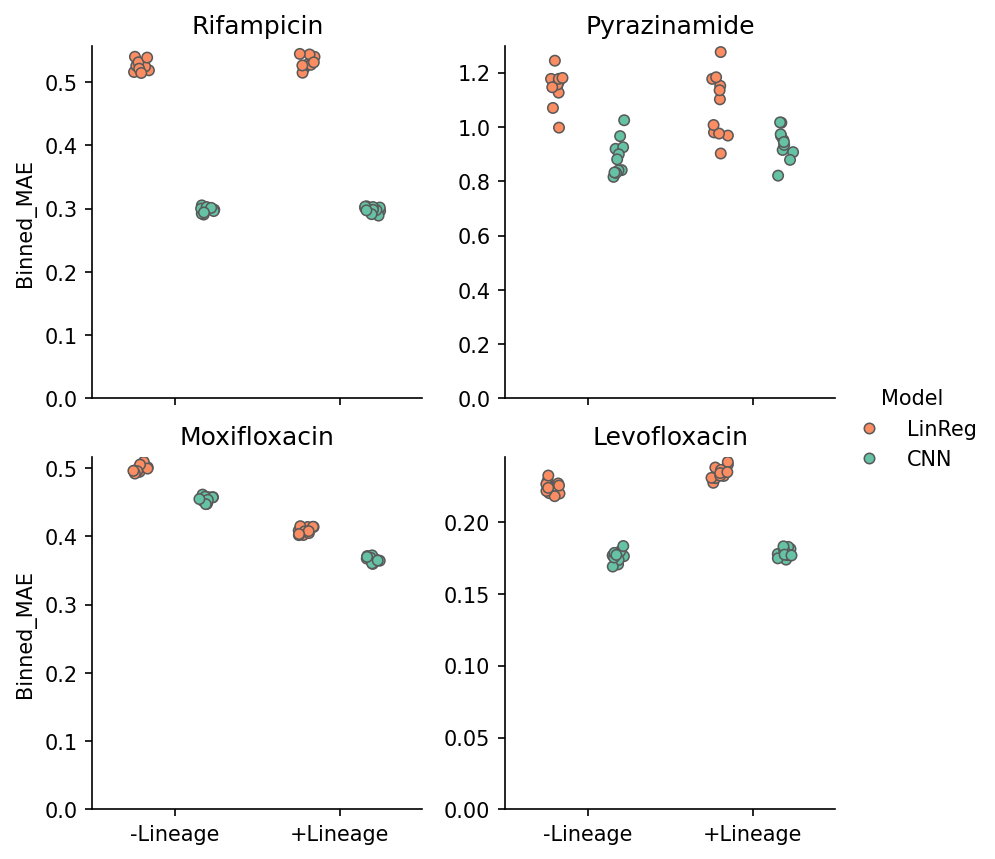

In [16]:
plot_var = "Binned_MAE"
plot_quant_variable_all_drugs(plot_var, all_drugs_results, drug_order=["RIF", "PZA", "MXF", "LEV"], lower_bound=0)#, saveName="train_test_MAE_4Drugs.png")

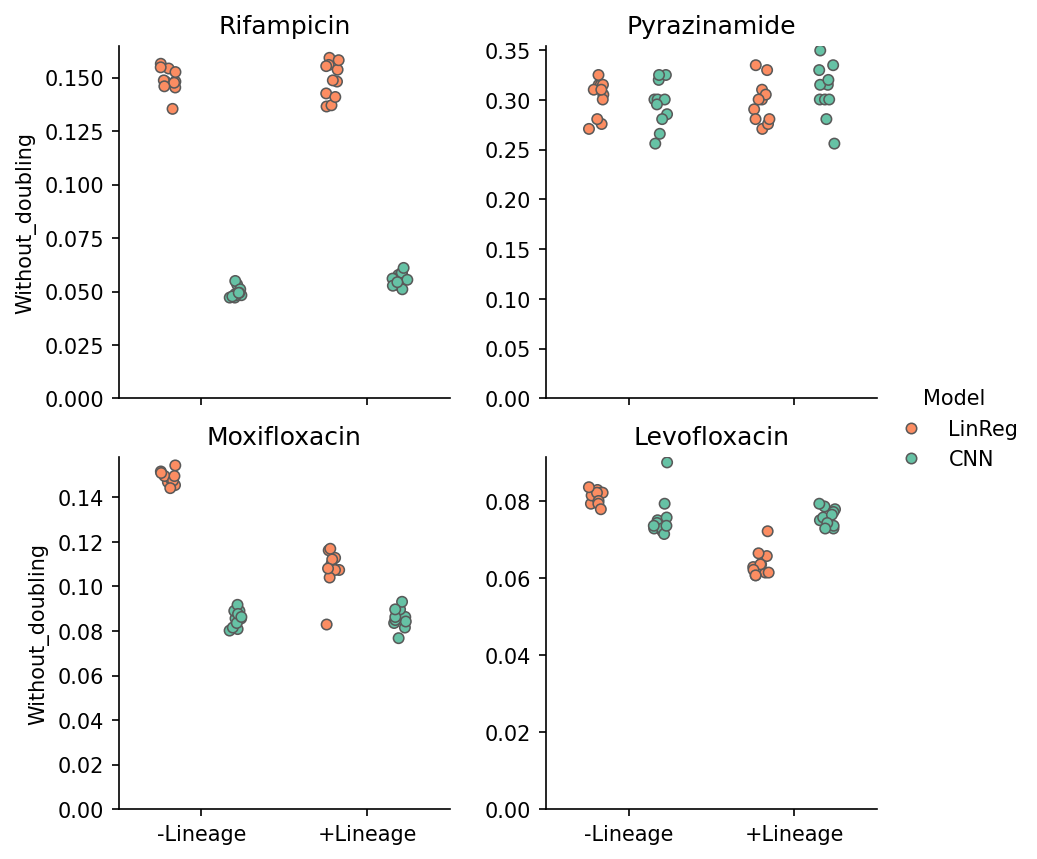

In [17]:
plot_var = "Without_doubling"
plot_quant_variable_all_drugs(plot_var, all_drugs_results, drug_order=["RIF", "PZA", "MXF", "LEV"], lower_bound=0)#, saveName="train_test_EA_4Drugs.png")

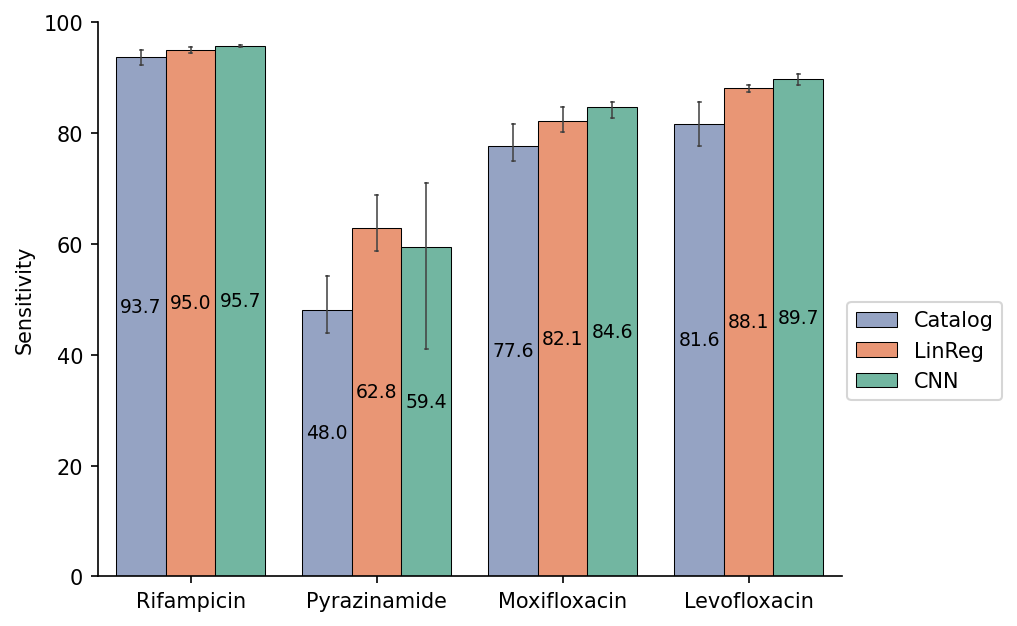

In [26]:
plot_var = "Sensitivity"
df_binary_results = plot_binary_variable_all_drugs(plot_var, all_drugs_results, all_drugs_catalog_results, drug_order=["RIF", "PZA", "MXF", "LEV"], saveName="sensitivity_with_catalog.png")

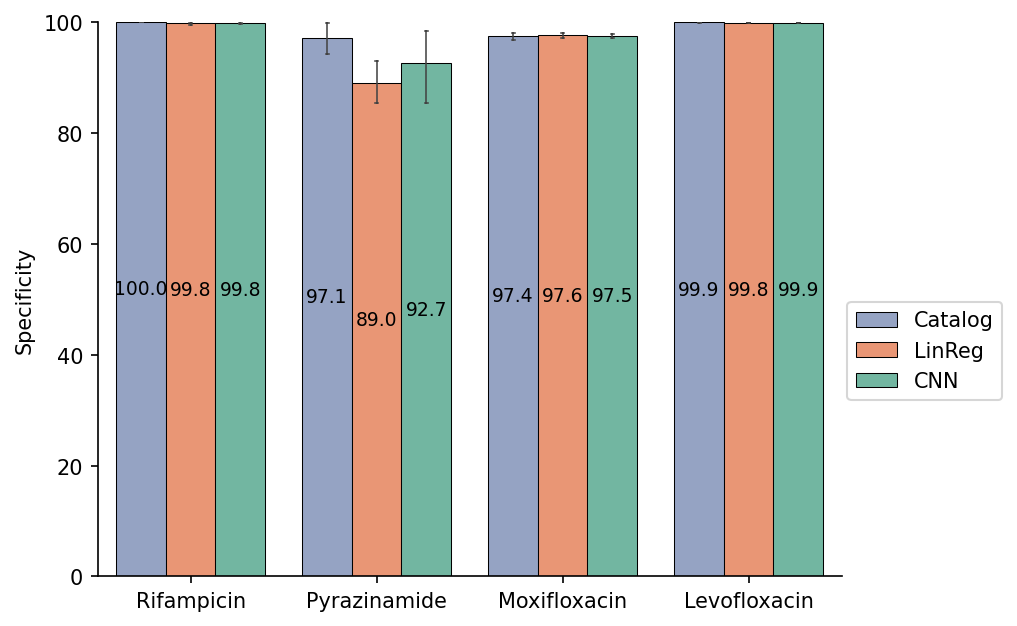

In [31]:
plot_var = "Specificity"
_ = plot_binary_variable_all_drugs(plot_var, all_drugs_results, all_drugs_catalog_results, drug_order=["RIF", "PZA", "MXF", "LEV"], saveName="specificity_with_catalog.png")

In [194]:
all_drugs_results.query("Drug=='PZA'")

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV,Lineage,Without_doubling
0,PZA,CNN,4,1.049653,6.761839,1.609495,11.182361,0.674877,0.651580,0.418539,0.548077,0.939394,0.904762,0.738916,0.743735,0,-Lineage,0.325123
1,PZA,CNN,4,1.188359,6.157491,1.770375,10.408337,0.645320,0.583869,0.399772,0.538462,0.888889,0.835821,0.709360,0.713675,1,-Lineage,0.354680
2,PZA,CNN,4,1.362954,2.984792,1.910366,5.519354,0.349754,0.457823,0.361222,0.346154,0.989899,0.972973,0.660099,0.668026,2,-Lineage,0.650246
3,PZA,CNN,4,1.190351,5.302475,1.778993,9.827190,0.640394,0.584558,0.415261,0.519231,0.939394,0.900000,0.724138,0.729312,3,-Lineage,0.359606
4,PZA,CNN,4,0.981439,6.125257,1.616871,11.080102,0.714286,0.651303,0.443589,0.644231,0.909091,0.881579,0.773399,0.776661,4,-Lineage,0.285714
5,PZA,CNN,4,1.194560,9.473884,1.769741,14.604797,0.645320,0.587120,0.374319,0.548077,0.939394,0.904762,0.738916,0.743735,5,-Lineage,0.354680
6,PZA,CNN,4,0.948712,3.008293,1.541411,5.948942,0.669951,0.649814,0.532522,0.576923,0.919192,0.882353,0.743842,0.748057,6,-Lineage,0.330049
7,PZA,CNN,4,1.198551,3.153382,1.800224,6.557600,0.615764,0.605035,0.441522,0.519231,0.909091,0.857143,0.709360,0.714161,7,-Lineage,0.384236
8,PZA,CNN,4,1.118875,4.596407,1.678549,7.917582,0.674877,0.591540,0.445390,0.519231,0.919192,0.870968,0.714286,0.719211,8,-Lineage,0.325123
9,PZA,CNN,4,0.922591,2.613833,1.525953,5.309949,0.665025,0.642353,0.572217,0.625000,0.909091,0.878378,0.763547,0.767045,9,-Lineage,0.334975


# Rifampicin

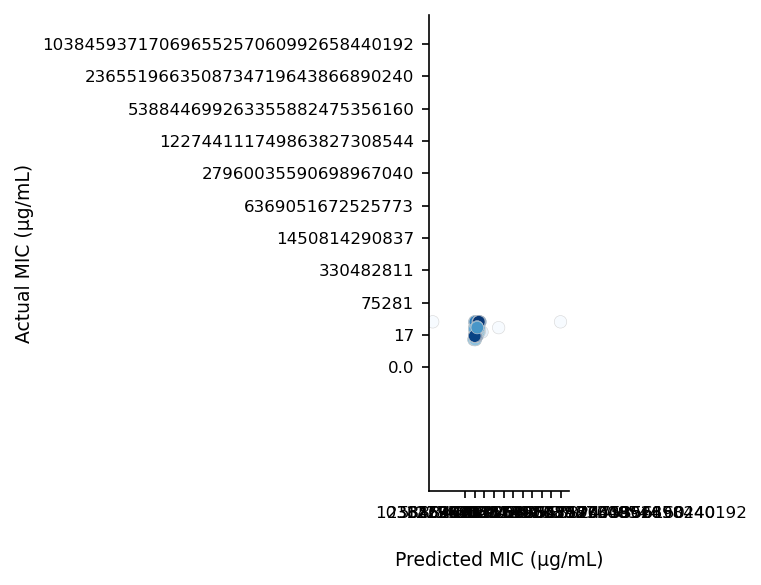

In [151]:
plot_ridge_results(os.path.join(results_path, "PZA_4Loci"), )#saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))

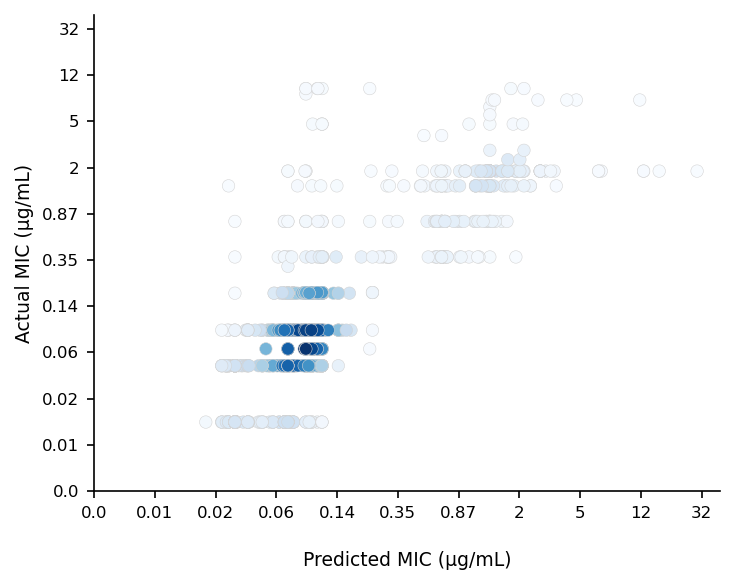

In [11]:
plot_ridge_results(os.path.join(results_path, "MXF_gyrBA_lineage"), )#saveName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, "RIF_rpoBC_lineage"))

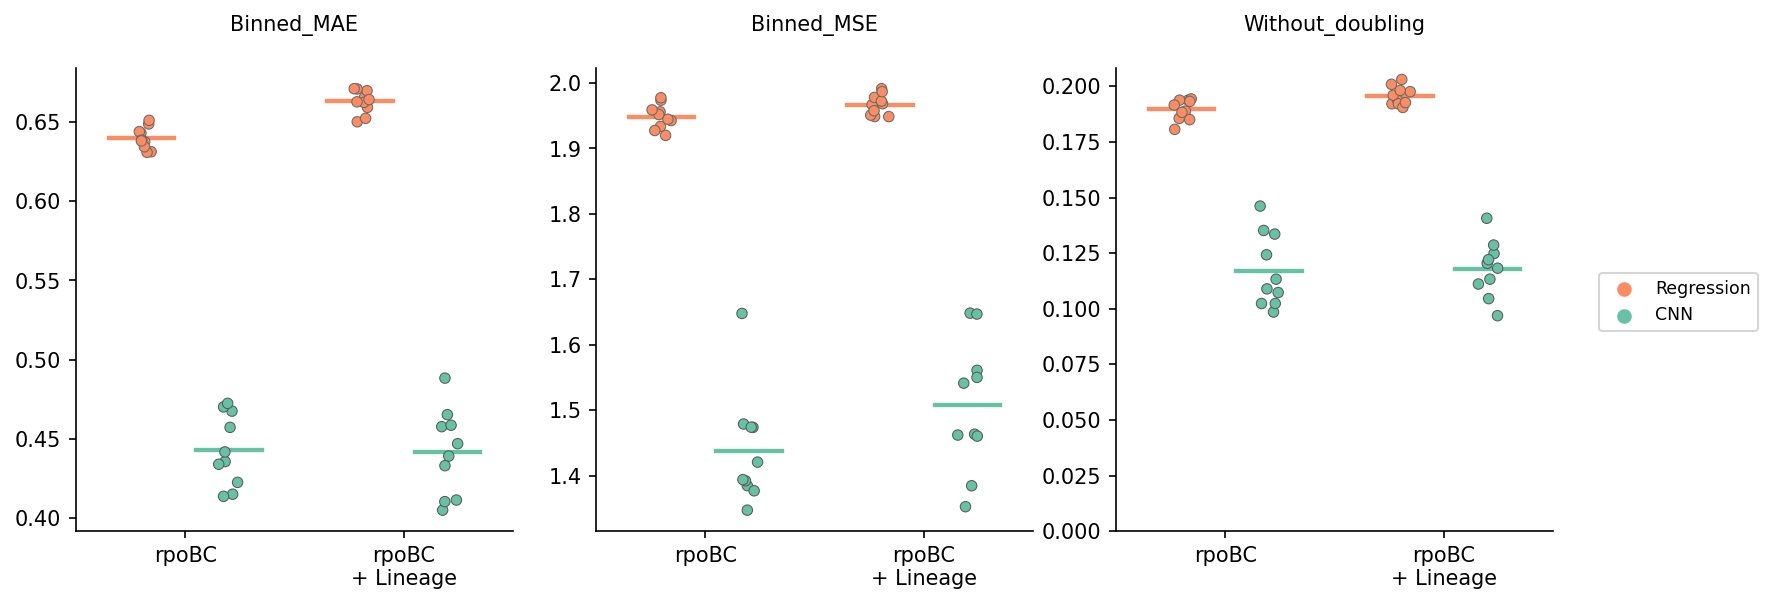

In [9]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_doubling"]

plot_model_results(df_RIF, variable_lst, ["rpoBC", "rpoBC\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, None], 
                   savefName="Rifampicin/quantitative_metrics.png"
                  )

# Distribution of Mispredictions

In [27]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    fig, ax = plt.subplots()
    sns.histplot(pred.y_pred - pred.y_test, stat="probability", ax=ax)
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="black", linestyle="-")
    
    print(f"Average Error: {np.round(np.mean(pred.y_pred - pred.y_test), 2)}")
    #ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

In [29]:
# error_dist("RIF_rpoBC")

In [56]:
# error_dist("RIF_rpoBC_lineage")

In [25]:
df_pred_CNN = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/test_predictions.csv"))
df_pred_Reg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/ridge/test_predictions.csv"))

In [42]:
RIF_test_variants = RIF_isolate_variants.query("Isolate in @df_pred_CNN.Isolate.values")
RIF_test_variants["mutation"] = RIF_test_variants["GENE"] + "_" + RIF_test_variants["PROT"]

cat1_mutations = who_variants_clean.query("drug == 'RIF' & confidence=='1) Assoc w R'").mutation.values
isolates_R = RIF_test_variants.query("mutation in @cat1_mutations & FILTER == 'PASS'").Isolate.values

In [64]:
df_pred_catalog = df_pred_CNN[["Isolate", "y_test_exp"]]
df_pred_catalog["y_test"] = (df_pred_CNN["y_test_exp"] > 0.5).astype(int)
df_pred_catalog["y_pred"] = df_pred_catalog["Isolate"].map(dict(zip(isolates_R, np.ones(len(isolates_R)))))
df_pred_catalog["y_pred"] = df_pred_catalog["y_pred"].fillna(0).astype(int)

In [65]:
df_pred_catalog

,Isolate,y_test_exp,y_test,y_pred
0,ERR4810495,0.090,0,0
1,ERR4810512,0.030,0,0
2,ERR4810526,0.030,0,0
3,ERR4810535,0.030,0,0
4,ERR4810584,0.030,0,0
...,...,...,...,...
1822,SAMN02380986,0.185,0,0
1823,SAMN02364077,16.000,1,1
1824,SAMEA3558171,120.000,1,1
1825,SAMEA3558209,120.000,1,1


In [66]:
df_pred_catalog.query("y_test != y_pred")

,Isolate,y_test_exp,y_test,y_pred
11,ERR4810867,4.000,1,0
15,ERR4810933,4.000,1,0
18,ERR4810962,4.000,1,0
80,ERR4810726,3.000,1,0
107,ERR4810780,0.750,1,0
...,...,...,...,...
1754,Peru5141,50.000,1,0
1763,Peru5447,50.000,1,0
1766,TDR105S128L002,0.875,1,0
1809,SAMN02360567,16.000,1,0


In [83]:
pd.concat([rif_CNN, rif_Reg], axis=0).drop_duplicates(["Model", "CV"], keep="first").shape

(22, 18)

In [84]:
pd.concat([rif_CNN, rif_Reg], axis=0).to_csv("Rifampicin/CNN_Reg_results.csv", index=False)